### Model Training
#### This notebook is to train each model and evaluate which one is the best using MLFlow
#### Firstly load data and model from notebook 2

In [37]:
import numpy as np
import joblib
import pandas as pd
from imblearn.over_sampling import SMOTE  
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score

# Load the preprocessed data from .npy files
X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')
network_dataset_encoder = joblib.load('../models/label_encoder.pkl')
network_dataset_scaler = joblib.load('../models/network_dataset_scaler.pkl')

# Test the shapes of the loaded data
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'y_test shape: {y_test.shape}')

# Test y_train distribution

print('y_train distribution:')
print(pd.Series(network_dataset_encoder.inverse_transform(y_train)).value_counts())

# Test the statistics of X_train
print(f'Mean: {X_train.mean():.4f}')
print(f'Std: {X_train.std():.4f}')
print(f'Min: {X_train.min():.4f}')
print(f'Max: {X_train.max():.4f}')

X_train shape: (2016638, 51)
X_test shape: (504160, 51)
y_train shape: (2016638,)
y_test shape: (504160,)
y_train distribution:
BENIGN                        1676045
DoS Hulk                       138277
DDoS                           102411
PortScan                        72555
DoS GoldenEye                    8229
FTP-Patator                      4745
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1558
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - Sql Injection         17
Heartbleed                          9
Name: count, dtype: int64
Mean: -0.0000
Std: 1.0000
Min: -1293.9682
Max: 1164.5381


I will now look at applying SMOTE to attacks that are balanced below 1000 readings as this is the natural gap and bring them up to the next natural gap of 1558
I have used the k_neighbours of 8 as the lowest class being 9

In [38]:
# Attacks distribution before SMOTE
print('y_train distribution before SMOTE:')
print(pd.Series(network_dataset_encoder.inverse_transform(y_train)).value_counts())

# Get value counts of the encoded labels
class_distribution = pd.Series(y_train).value_counts().sort_index()


# Create sampling strategy: bring minority classes up to 1558
sampling_threshold = 1000
sampling_target = 1558
sampling_strat = {}
for label, count in class_distribution.items():
    if count < sampling_threshold:
        sampling_strat[label] = sampling_target




smote = SMOTE(random_state=42, k_neighbors=8, sampling_strategy=sampling_strat)  # Adjust k_neighbors based on the number of samples in the minority class

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)



# Attacks distribution after SMOTE
print('y_train distribution after SMOTE:')
print(pd.Series(network_dataset_encoder.inverse_transform(y_train_resampled)).value_counts())

print(f'X_train_resampled shape: {X_train_resampled.shape}')
print(f'y_train_resampled shape: {y_train_resampled.shape}')

np.save('../data/processed/X_train_resampled.npy', X_train_resampled)
np.save('../data/processed/y_train_resampled.npy', y_train_resampled)

y_train distribution before SMOTE:
BENIGN                        1676045
DoS Hulk                       138277
DDoS                           102411
PortScan                        72555
DoS GoldenEye                    8229
FTP-Patator                      4745
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                      2575
Bot                              1558
Web Attack - Brute Force         1176
Web Attack - XSS                  522
Infiltration                       29
Web Attack - Sql Injection         17
Heartbleed                          9
Name: count, dtype: int64
y_train distribution after SMOTE:
BENIGN                        1676045
DoS Hulk                       138277
DDoS                           102411
PortScan                        72555
DoS GoldenEye                    8229
FTP-Patator                      4745
DoS slowloris                    4308
DoS Slowhttptest                 4182
SSH-Patator                    

Now to start fitting the models to compare results - firstly RandomForestClassifier

In [44]:
# Train the Random Forest Classifier
network_dataset_rfc = RandomForestClassifier(n_estimators=100, random_state=42)
network_dataset_rfc.fit(X_train_resampled, y_train_resampled)
joblib.dump(network_dataset_rfc, '../models/network_dataset_rfc.pkl')

# Evaluate the classifier on the test set
y_pred_rfc = network_dataset_rfc.predict(X_test)

# Calculate and print evaluation metrics
print('Random Forest Classifier trained and saved successfully.')
print("Classifier performance on the test set:  ")
f1_score_macro_rfc = f1_score(y_test, y_pred_rfc, average='macro')
classification_rep_rfc = classification_report(y_test, y_pred_rfc, target_names=network_dataset_encoder.classes_)
conf_matrix_rfc = confusion_matrix(y_test, y_pred_rfc)
print(f'F1 Score (Macro): {f1_score_macro_rfc:.4f}')
print('Classification Report:')
print(classification_rep_rfc)
print('Confusion Matrix:')
print(conf_matrix_rfc)




Random Forest Classifier trained and saved successfully.
Classifier performance on the test set:  
F1 Score (Macro): 0.8757
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.89      0.78      0.83       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      0.99      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       1.00      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      0.99      0.99     18139
               SSH-Patator       1.0

First I will save the reports for MLFlow

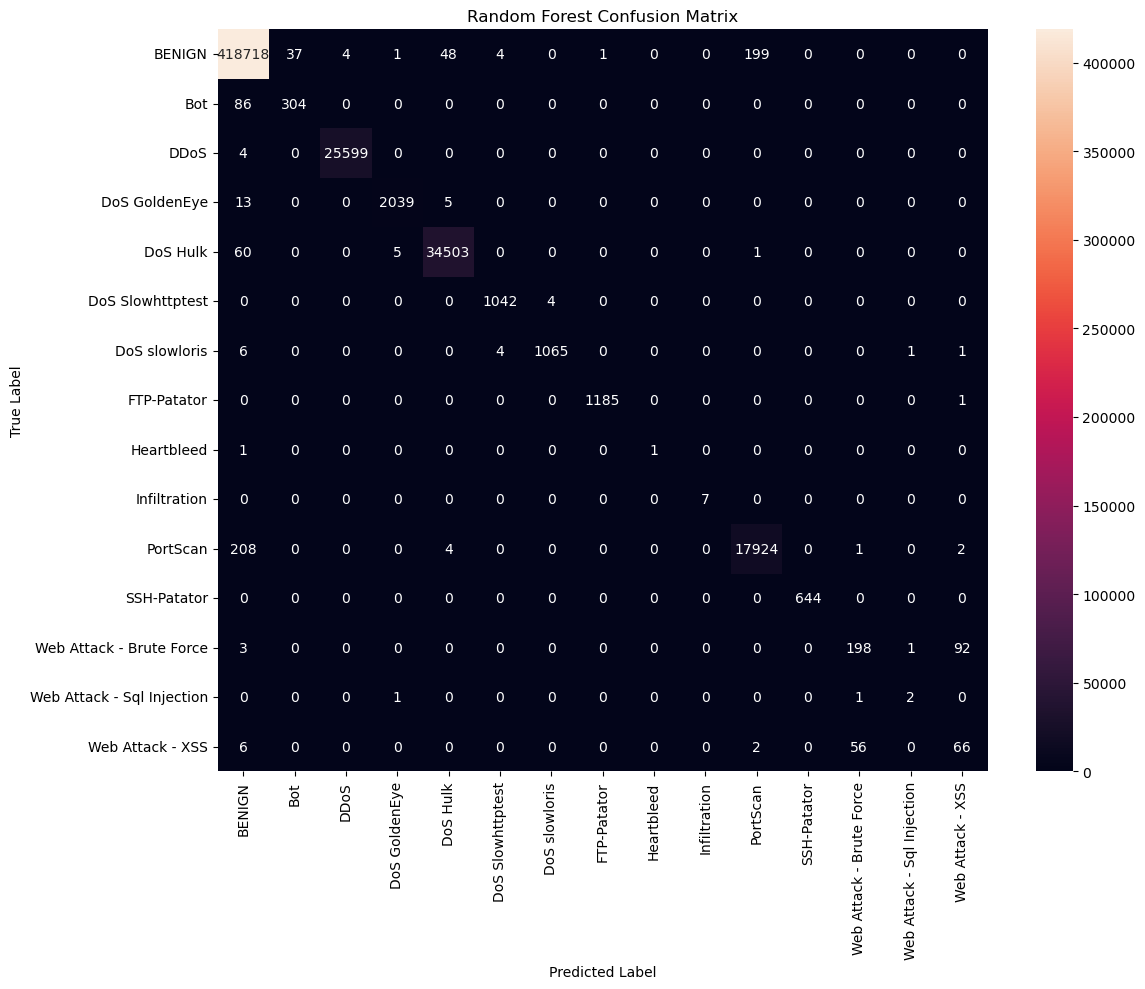

In [45]:
# Confusion matrix as an image
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_rfc, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('Random Forest Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/rf_confusion_matrix.png')


with open('../reports/classification_report_rf.txt', 'w') as f:
    f.write(classification_rep_rfc)

Heartbleed (n=2) and Web Attack - SQL Injection (n=4) have insufficient test samples for reliable metric interpretation. Results for these classes should be treated as indicative only.
Implmenting MLFlow for the RFC model

In [ ]:

# Log the model and metrics to MLflow
import mlflow

report_dict_rfc = classification_report(y_test, y_pred_rfc, output_dict=True)

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="random_forest_baseline",):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("f1_macro", f1_score_macro_rfc)
    mlflow.log_metric("recall", report_dict_rfc['macro avg']['recall'])
    mlflow.log_metric("precision", report_dict_rfc['macro avg']['precision'])
    mlflow.log_artifact("../reports/classification_report_rfc.txt")
    mlflow.log_artifact("../reports/rf_confusion_matrix.png")
    mlflow.sklearn.log_model(network_dataset_rfc, name="model")


2026/04/03 15:19:57 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [32]:
mlflow.end_run()

I will now laod and fit XGBoost model as the 2nd model to compare throughout each mdoel

In [ ]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight='balanced', y = y_train)
network_dataset_xgb = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', objective='multi:softmax', num_class=len(network_dataset_encoder.classes_))
network_dataset_xgb.fit(X_train, y_train, sample_weight=sample_weights)
joblib.dump(network_dataset_xgb, '../models/network_dataset_xgb.pkl')



XGBoost Classifier trained and saved successfully.
Classifier performance on the test set:  
F1 Score (Macro): 0.9036
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.68      0.99      0.81       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      1.00      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00     

In [52]:
y_pred_xgb = network_dataset_xgb.predict(X_test)

# Calculate and print evaluation metrics
print('XGBoost Classifier trained and saved successfully.')
print("Classifier performance on the test set:  ")
f1_score_macro_xgb = f1_score(y_test, y_pred_xgb, average='macro')
classification_report_xgb = classification_report(y_test, y_pred_xgb, target_names=network_dataset_encoder.classes_)
conf_matrix_xgb = confusion_matrix(y_test, y_pred_xgb)
print(f'F1 Score (Macro): {f1_score_macro_xgb:.4f}')
print('Classification Report:')
print(classification_report_xgb)
print('Confusion Matrix:')
print(conf_matrix_xgb)

XGBoost Classifier trained and saved successfully.
Classifier performance on the test set:  
F1 Score (Macro): 0.9036
Classification Report:
                            precision    recall  f1-score   support

                    BENIGN       1.00      1.00      1.00    419012
                       Bot       0.68      0.99      0.81       390
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       0.99      1.00      0.99      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.99      1.00      0.99      1046
             DoS slowloris       0.99      0.99      0.99      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      1.00      1.00         2
              Infiltration       1.00      1.00      1.00         7
                  PortScan       0.99      1.00      0.99     18139
               SSH-Patator       1.00     

In [41]:
print("Unique predicted classes:", np.unique(y_pred_xgb))
print("Predicted class distribution:")
print(pd.Series(network_dataset_encoder.inverse_transform(y_pred_xgb)).value_counts())

Unique predicted classes: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Predicted class distribution:
BENIGN                        423000
PortScan                       19956
Bot                            13845
DoS Hulk                       13271
DoS GoldenEye                  10589
Web Attack - XSS                7712
Web Attack - Sql Injection      4112
DoS slowloris                   4040
Web Attack - Brute Force        3037
DoS Slowhttptest                1597
FTP-Patator                     1576
Infiltration                    1239
SSH-Patator                      171
DDoS                              11
Heartbleed                         4
Name: count, dtype: int64


XGBoost was trained on the original imbalanced training data using compute_sample_weight(class_weight='balanced') to handle class imbalance, rather than the SMOTE-resampled data used for Random Forest. This means the two models are not directly comparable on identical training data — a limitation worth noting when interpreting the results. Sample weighting is a valid alternative to oversampling and is native to XGBoost's training process.

Now adding to MLFlow

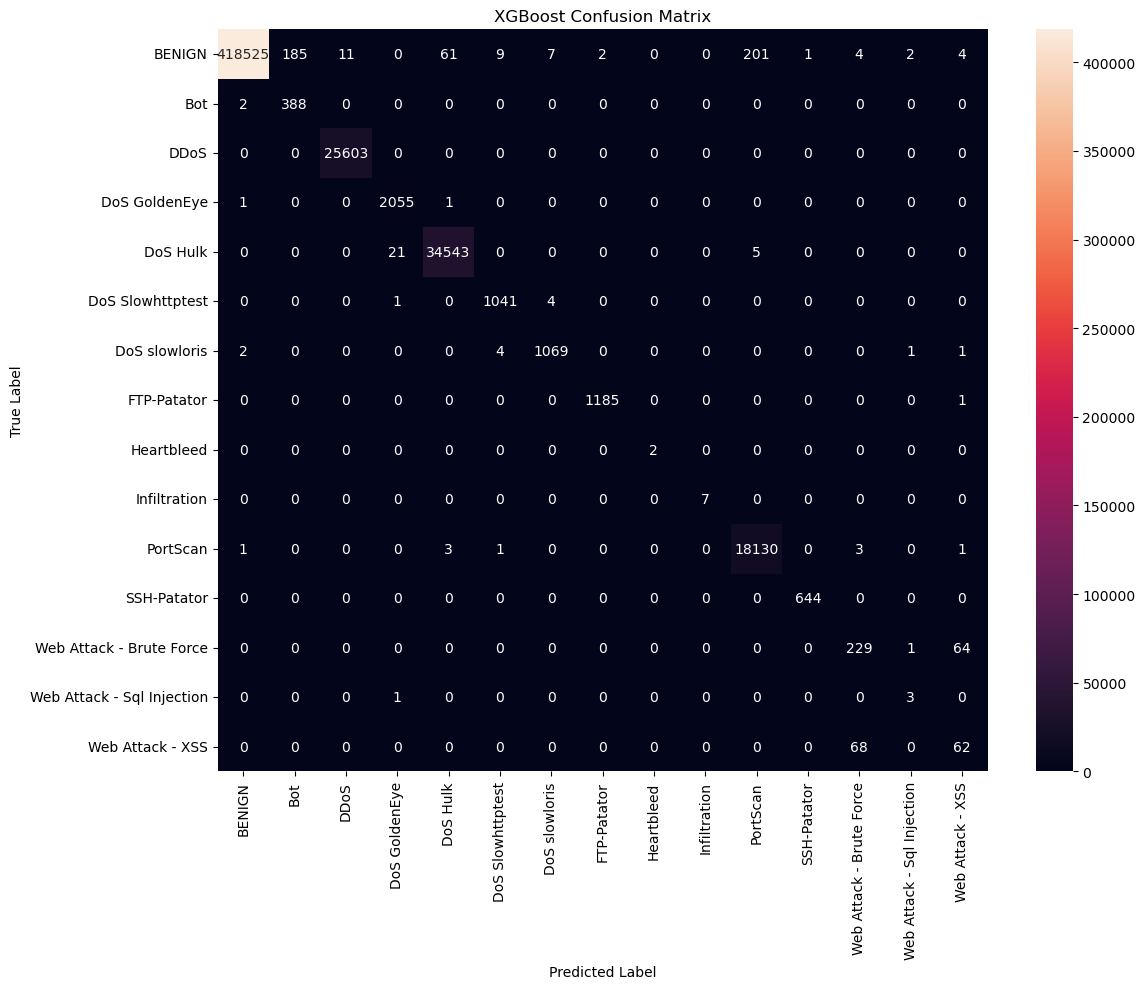

In [55]:
plt.figure(figsize=(12, 10))
sns.heatmap(conf_matrix_xgb, annot=True, fmt='d', 
            xticklabels=network_dataset_encoder.classes_, 
            yticklabels=network_dataset_encoder.classes_)
plt.title('XGBoost Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../reports/xgb_confusion_matrix.png')


with open('../reports/classification_report_xgb.txt', 'w') as f:
    f.write(classification_report_xgb)

In [56]:
report_dict_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)

mlflow.set_experiment("network-anomaly-detector")

with mlflow.start_run(run_name="XGBoost_baseline",):
    mlflow.log_param("n_estimators", 100)
    mlflow.log_metric("f1_macro", f1_score_macro_xgb)
    mlflow.log_metric("recall", report_dict_xgb['macro avg']['recall'])
    mlflow.log_metric("precision", report_dict_xgb['macro avg']['precision'])
    mlflow.log_artifact("../reports/classification_report_xgb.txt")
    mlflow.log_artifact("../reports/xgb_confusion_matrix.png")
    mlflow.sklearn.log_model(network_dataset_xgb, name="model")

2026/04/03 18:35:52 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
